In [27]:
import pandas as pd
NE2 = pd.read_csv("BD_NE2_limpia.csv")
NE3 = pd.read_csv("BD_NE3_limpia.csv")
evi = pd.read_csv("EVI_estaciones.csv")

In [28]:
evi.head()

,estacion,fecha,EVI
0,NE2,2021-01-01,0.0638
1,NE2,2021-01-17,0.0840
2,NE2,2021-02-02,0.0691
3,NE2,2021-02-18,0.0556
4,NE2,2021-03-06,0.0811


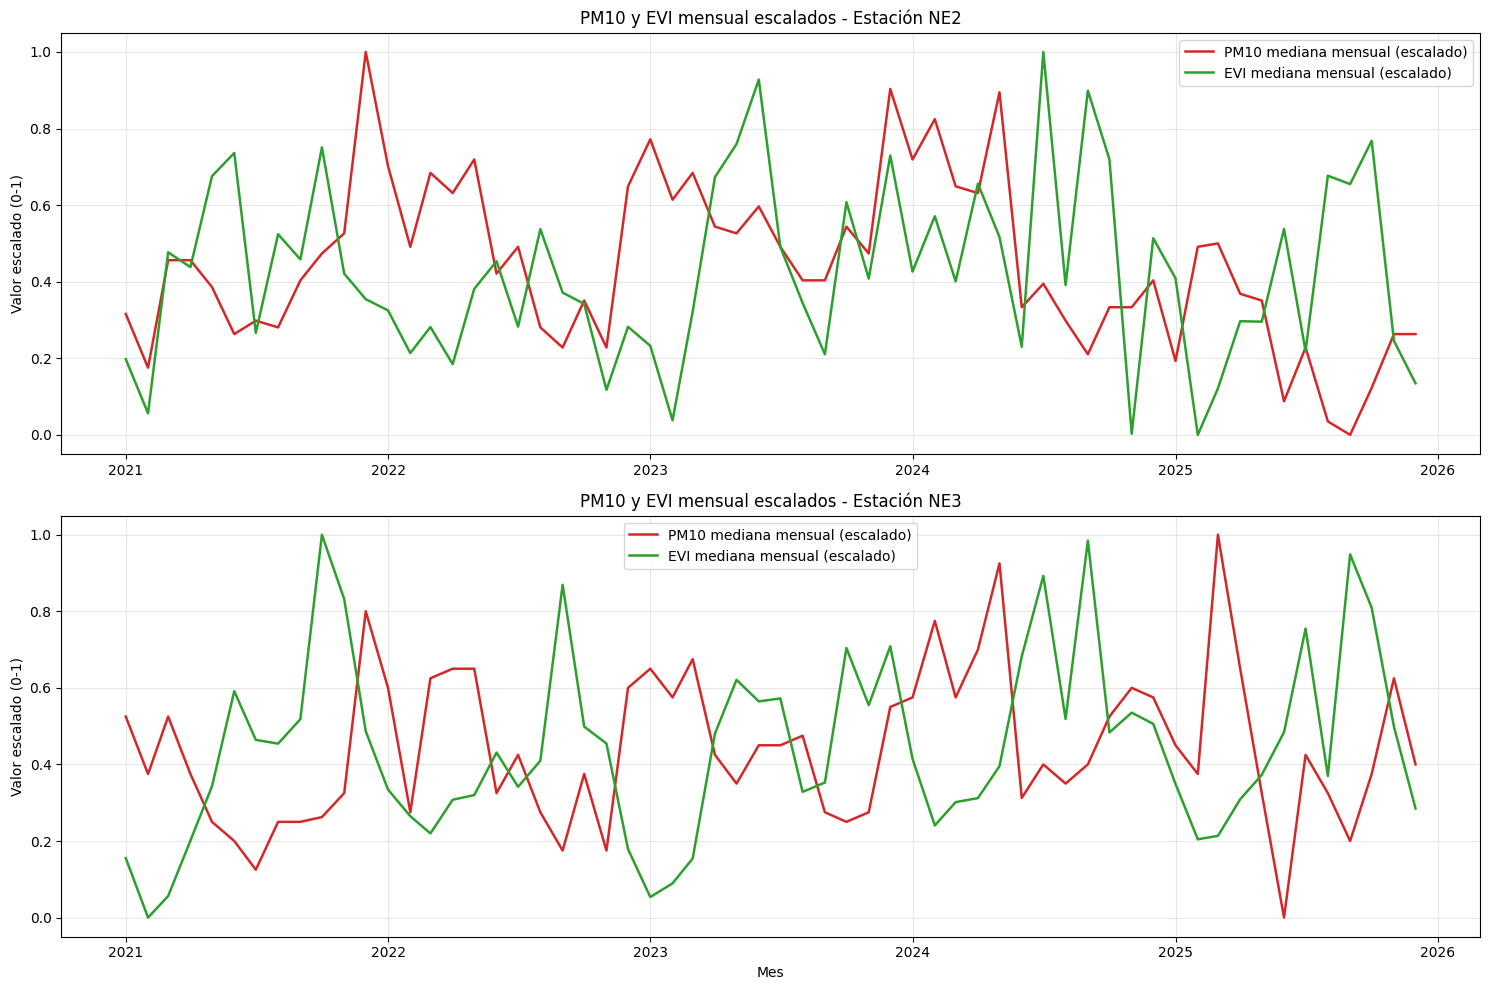

(         mes  pm10_mediana  evi_mediana  pm10_escalado  evi_escalado
 0 2021-01-01          52.0      0.07390       0.315789      0.197674
 1 2021-02-01          44.0      0.06235       0.175439      0.056304
 2 2021-03-01          60.0      0.09670       0.456140      0.476744
 3 2021-04-01          60.0      0.09355       0.456140      0.438188
 4 2021-05-01          56.0      0.11295       0.385965      0.675643,
          mes  pm10_mediana  evi_mediana  pm10_escalado  evi_escalado
 0 2021-01-01          36.0      0.15705          0.525      0.155317
 1 2021-02-01          30.0      0.11440          0.375      0.000000
 2 2021-03-01          36.0      0.12985          0.525      0.056264
 3 2021-04-01          30.0      0.16960          0.375      0.201020
 4 2021-05-01          25.0      0.20860          0.250      0.343044)

In [29]:
import matplotlib.pyplot as plt
import pandas as pd


def escalar_min_max(serie):
    """Escala una serie al intervalo [0, 1], ignorando valores faltantes."""
    minimo = serie.min()
    maximo = serie.max()
    if pd.isna(minimo) or minimo == maximo:
        return serie * 0
    return (serie - minimo) / (maximo - minimo)


def agregar_evi_mensual(datos_evi):
    """Convierte el EVI quincenal en mediana mensual por estación."""
    datos_evi = datos_evi.copy()
    datos_evi["fecha"] = pd.to_datetime(datos_evi["fecha"])  # ajusta el nombre de columna si es distinto
    datos_evi["mes"] = datos_evi["fecha"].dt.to_period("M").dt.to_timestamp()
    datos_evi["EVI"] = pd.to_numeric(datos_evi["EVI"], errors="coerce")

    evi_mensual = (
        datos_evi
        .groupby(["estacion", "mes"], as_index=False)["EVI"]
        .median()
        .rename(columns={"EVI": "evi_mediana"})
    )
    return evi_mensual


def preparar_datos_estacion(datos_pm10, evi_mensual, nombre_estacion):
    """Agrega PM10 por mes y lo combina con el EVI mensual."""
    pm10_mensual = (
        datos_pm10.assign(
            mes=datos_pm10["date"].dt.to_period("M").dt.to_timestamp(),
            PM10=pd.to_numeric(datos_pm10["PM10"], errors="coerce"),
        )
        .groupby("mes", as_index=False)["PM10"]
        .median()
        .rename(columns={"PM10": "pm10_mediana"})
    )

    evi_estacion = evi_mensual.loc[
        evi_mensual["estacion"] == nombre_estacion,
        ["mes", "evi_mediana"],
    ]
    datos = pm10_mensual.merge(evi_estacion, on="mes", how="inner")
    datos = datos.sort_values("mes")
    datos["pm10_escalado"] = escalar_min_max(datos["pm10_mediana"])
    datos["evi_escalado"] = escalar_min_max(datos["evi_mediana"])
    return datos


# Preparación de tipos de fecha
NE2["date"] = pd.to_datetime(NE2["date"])
NE3["date"] = pd.to_datetime(NE3["date"])

# Agregamos el EVI quincenal a mensual (una sola vez para todas las estaciones)
evi_mensual = agregar_evi_mensual(evi)  # reemplaza "evi" por el nombre real de tu DataFrame

serie_NE2 = preparar_datos_estacion(NE2, evi_mensual, "NE2")
serie_NE3 = preparar_datos_estacion(NE3, evi_mensual, "NE3")

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

for eje, datos, nombre_estacion in zip(
    ejes,
    [serie_NE2, serie_NE3],
    ["NE2", "NE3"],
):
    eje.plot(
        datos["mes"],
        datos["pm10_escalado"],
        label="PM10 mediana mensual (escalado)",
        color="tab:red",
        linewidth=1.8,
    )
    eje.plot(
        datos["mes"],
        datos["evi_escalado"],
        label="EVI mediana mensual (escalado)",
        color="tab:green",
        linewidth=1.8,
    )
    eje.set_title(f"PM10 y EVI mensual escalados - Estación {nombre_estacion}")
    eje.set_ylabel("Valor escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()

ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

serie_NE2.head(), serie_NE3.head()

In [30]:
ndvi_mensual = pd.read_csv("ndvi_mensual_estaciones_2020_2025.csv")

In [31]:
ndvi_mensual["mes"] = pd.to_datetime(ndvi_mensual["mes"])
evi_mensual["mes"] = pd.to_datetime(evi_mensual["mes"])

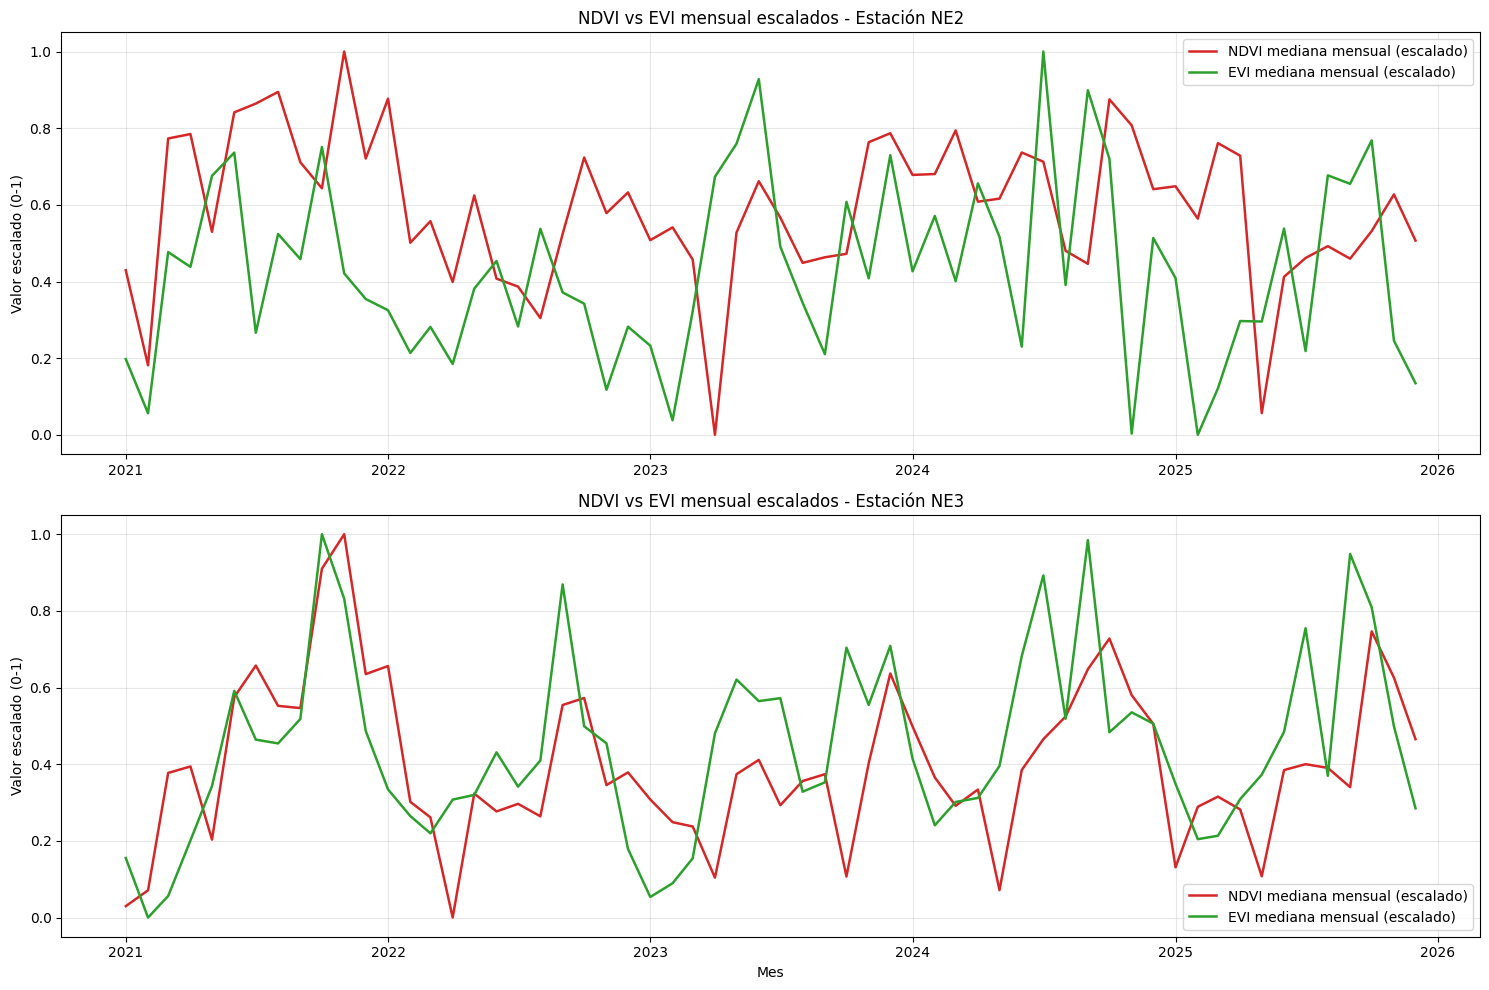

(         mes  ndvi_mediana  evi_mediana  ndvi_escalado  evi_escalado
 0 2021-01-01      0.035765      0.07390       0.429339      0.197674
 1 2021-02-01      0.016555      0.06235       0.181351      0.056304
 2 2021-03-01      0.062388      0.09670       0.773041      0.476744
 3 2021-04-01      0.063291      0.09355       0.784696      0.438188
 4 2021-05-01      0.043520      0.11295       0.529460      0.675643,
          mes  ndvi_mediana  evi_mediana  ndvi_escalado  evi_escalado
 0 2021-01-01      0.024677      0.15705       0.029719      0.155317
 1 2021-02-01      0.044841      0.11440       0.071137      0.000000
 2 2021-03-01      0.193872      0.12985       0.377256      0.056264
 3 2021-04-01      0.202109      0.16960       0.394176      0.201020
 4 2021-05-01      0.109191      0.20860       0.203317      0.343044)

In [32]:
def preparar_indices_estacion(nombre_estacion):
    """Combina NDVI y EVI mensuales para una estación, en la ventana temporal común."""
    ndvi_est = ndvi_mensual.loc[
        ndvi_mensual["estacion"] == nombre_estacion, ["mes", "ndvi_mediana"]
    ]
    evi_est = evi_mensual.loc[
        evi_mensual["estacion"] == nombre_estacion, ["mes", "evi_mediana"]
    ]

    datos = ndvi_est.merge(evi_est, on="mes", how="inner")  # solo meses con ambos índices
    datos = datos.sort_values("mes")
    datos["ndvi_escalado"] = escalar_min_max(datos["ndvi_mediana"])
    datos["evi_escalado"] = escalar_min_max(datos["evi_mediana"])
    return datos


serie_indices_NE2 = preparar_indices_estacion("NE2")
serie_indices_NE3 = preparar_indices_estacion("NE3")

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

for eje, datos, nombre_estacion in zip(
    ejes, [serie_indices_NE2, serie_indices_NE3], ["NE2", "NE3"]
):
    eje.plot(datos["mes"], datos["ndvi_escalado"], label="NDVI mediana mensual (escalado)",
              color="tab:red", linewidth=1.8)
    eje.plot(datos["mes"], datos["evi_escalado"], label="EVI mediana mensual (escalado)",
              color="tab:green", linewidth=1.8)
    eje.set_title(f"NDVI vs EVI mensual escalados - Estación {nombre_estacion}")
    eje.set_ylabel("Valor escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()

ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

serie_indices_NE2.head(), serie_indices_NE3.head()

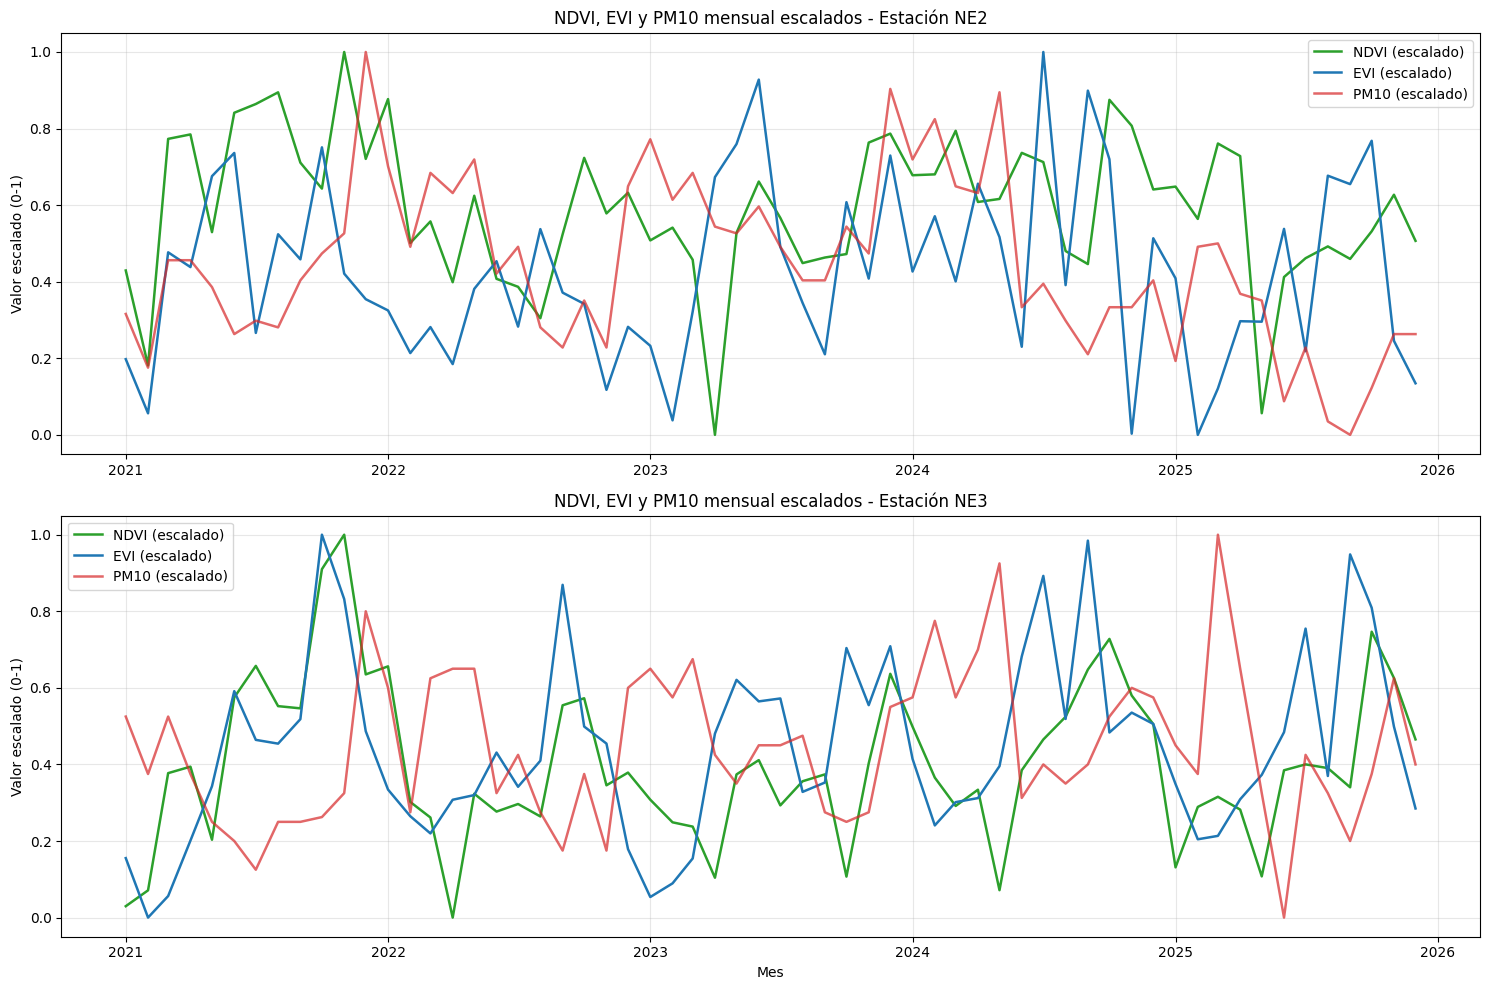

In [33]:
def preparar_indices_y_pm10_estacion(datos_pm10, nombre_estacion):
    """Combina NDVI, EVI y PM10 mensuales para una estación, en la ventana temporal común."""
    ndvi_mensual["mes"] = pd.to_datetime(ndvi_mensual["mes"])
    evi_mensual["mes"] = pd.to_datetime(evi_mensual["mes"])

    pm10_mensual = (
        datos_pm10.assign(
            mes=datos_pm10["date"].dt.to_period("M").dt.to_timestamp(),
            PM10=pd.to_numeric(datos_pm10["PM10"], errors="coerce"),
        )
        .groupby("mes", as_index=False)["PM10"]
        .median()
        .rename(columns={"PM10": "pm10_mediana"})
    )

    ndvi_est = ndvi_mensual.loc[ndvi_mensual["estacion"] == nombre_estacion, ["mes", "ndvi_mediana"]]
    evi_est = evi_mensual.loc[evi_mensual["estacion"] == nombre_estacion, ["mes", "evi_mediana"]]

    datos = ndvi_est.merge(evi_est, on="mes", how="inner").merge(pm10_mensual, on="mes", how="inner")
    datos = datos.sort_values("mes")
    datos["ndvi_escalado"] = escalar_min_max(datos["ndvi_mediana"])
    datos["evi_escalado"] = escalar_min_max(datos["evi_mediana"])
    datos["pm10_escalado"] = escalar_min_max(datos["pm10_mediana"])
    return datos


serie_completa_NE2 = preparar_indices_y_pm10_estacion(NE2, "NE2")
serie_completa_NE3 = preparar_indices_y_pm10_estacion(NE3, "NE3")

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

for eje, datos, nombre_estacion in zip(
    ejes, [serie_completa_NE2, serie_completa_NE3], ["NE2", "NE3"]
):
    eje.plot(datos["mes"], datos["ndvi_escalado"], label="NDVI (escalado)", color="tab:green", linewidth=1.8)
    eje.plot(datos["mes"], datos["evi_escalado"], label="EVI (escalado)", color="tab:blue", linewidth=1.8)
    eje.plot(datos["mes"], datos["pm10_escalado"], label="PM10 (escalado)", color="tab:red", linewidth=1.8, alpha=0.7)
    eje.set_title(f"NDVI, EVI y PM10 mensual escalados - Estación {nombre_estacion}")
    eje.set_ylabel("Valor escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()

ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

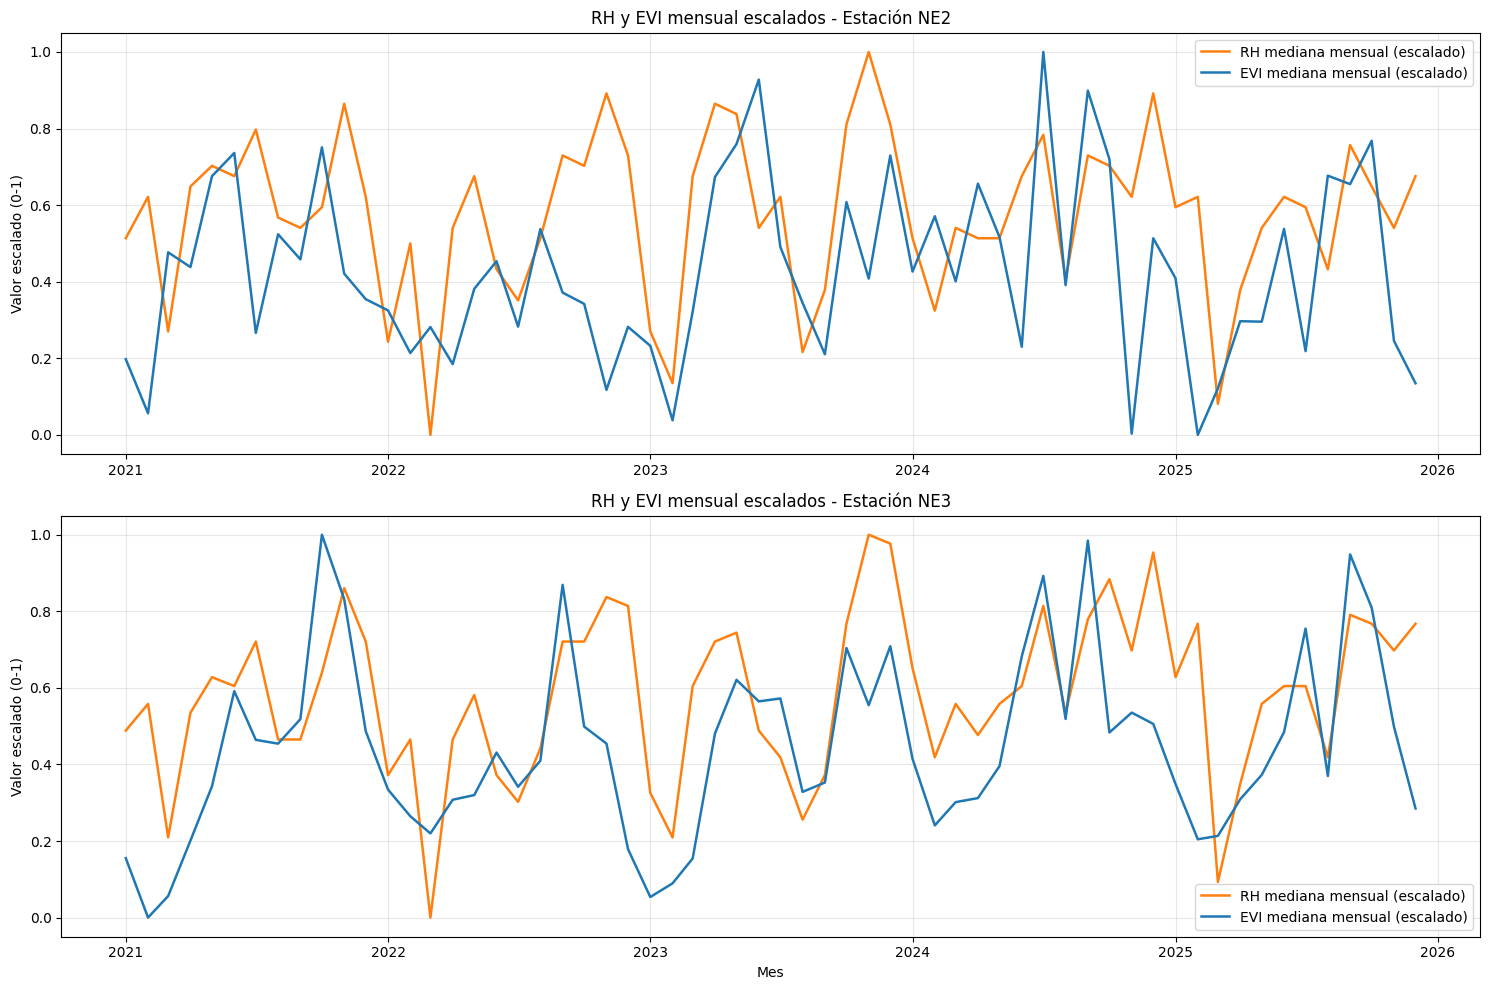

(         mes  rh_mediana  evi_mediana  rh_escalado  evi_escalado
 0 2021-01-01        55.0      0.07390     0.513514      0.197674
 1 2021-02-01        59.0      0.06235     0.621622      0.056304
 2 2021-03-01        46.0      0.09670     0.270270      0.476744
 3 2021-04-01        60.0      0.09355     0.648649      0.438188
 4 2021-05-01        62.0      0.11295     0.702703      0.675643,
          mes  rh_mediana  evi_mediana  rh_escalado  evi_escalado
 0 2021-01-01        60.0      0.15705     0.488372      0.155317
 1 2021-02-01        63.0      0.11440     0.558140      0.000000
 2 2021-03-01        48.0      0.12985     0.209302      0.056264
 3 2021-04-01        62.0      0.16960     0.534884      0.201020
 4 2021-05-01        66.0      0.20860     0.627907      0.343044)

In [34]:
def preparar_evi_rh_estacion(datos_estacion, nombre_estacion):
    """Agrega RH por mes y lo combina con el EVI mensual."""
    rh_mensual = (
        datos_estacion.assign(
            mes=datos_estacion["date"].dt.to_period("M").dt.to_timestamp(),
            RH=pd.to_numeric(datos_estacion["RH"], errors="coerce"),
        )
        .groupby("mes", as_index=False)["RH"]
        .median()
        .rename(columns={"RH": "rh_mediana"})
    )

    evi_mensual["mes"] = pd.to_datetime(evi_mensual["mes"])
    evi_est = evi_mensual.loc[evi_mensual["estacion"] == nombre_estacion, ["mes", "evi_mediana"]]

    datos = rh_mensual.merge(evi_est, on="mes", how="inner")
    datos = datos.sort_values("mes")
    datos["rh_escalado"] = escalar_min_max(datos["rh_mediana"])
    datos["evi_escalado"] = escalar_min_max(datos["evi_mediana"])
    return datos


serie_evi_rh_NE2 = preparar_evi_rh_estacion(NE2, "NE2")
serie_evi_rh_NE3 = preparar_evi_rh_estacion(NE3, "NE3")

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

for eje, datos, nombre_estacion in zip(
    ejes, [serie_evi_rh_NE2, serie_evi_rh_NE3], ["NE2", "NE3"]
):
    eje.plot(datos["mes"], datos["rh_escalado"], label="RH mediana mensual (escalado)",
              color="tab:orange", linewidth=1.8)
    eje.plot(datos["mes"], datos["evi_escalado"], label="EVI mediana mensual (escalado)",
              color="tab:blue", linewidth=1.8)
    eje.set_title(f"RH y EVI mensual escalados - Estación {nombre_estacion}")
    eje.set_ylabel("Valor escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()

ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

serie_evi_rh_NE2.head(), serie_evi_rh_NE3.head()

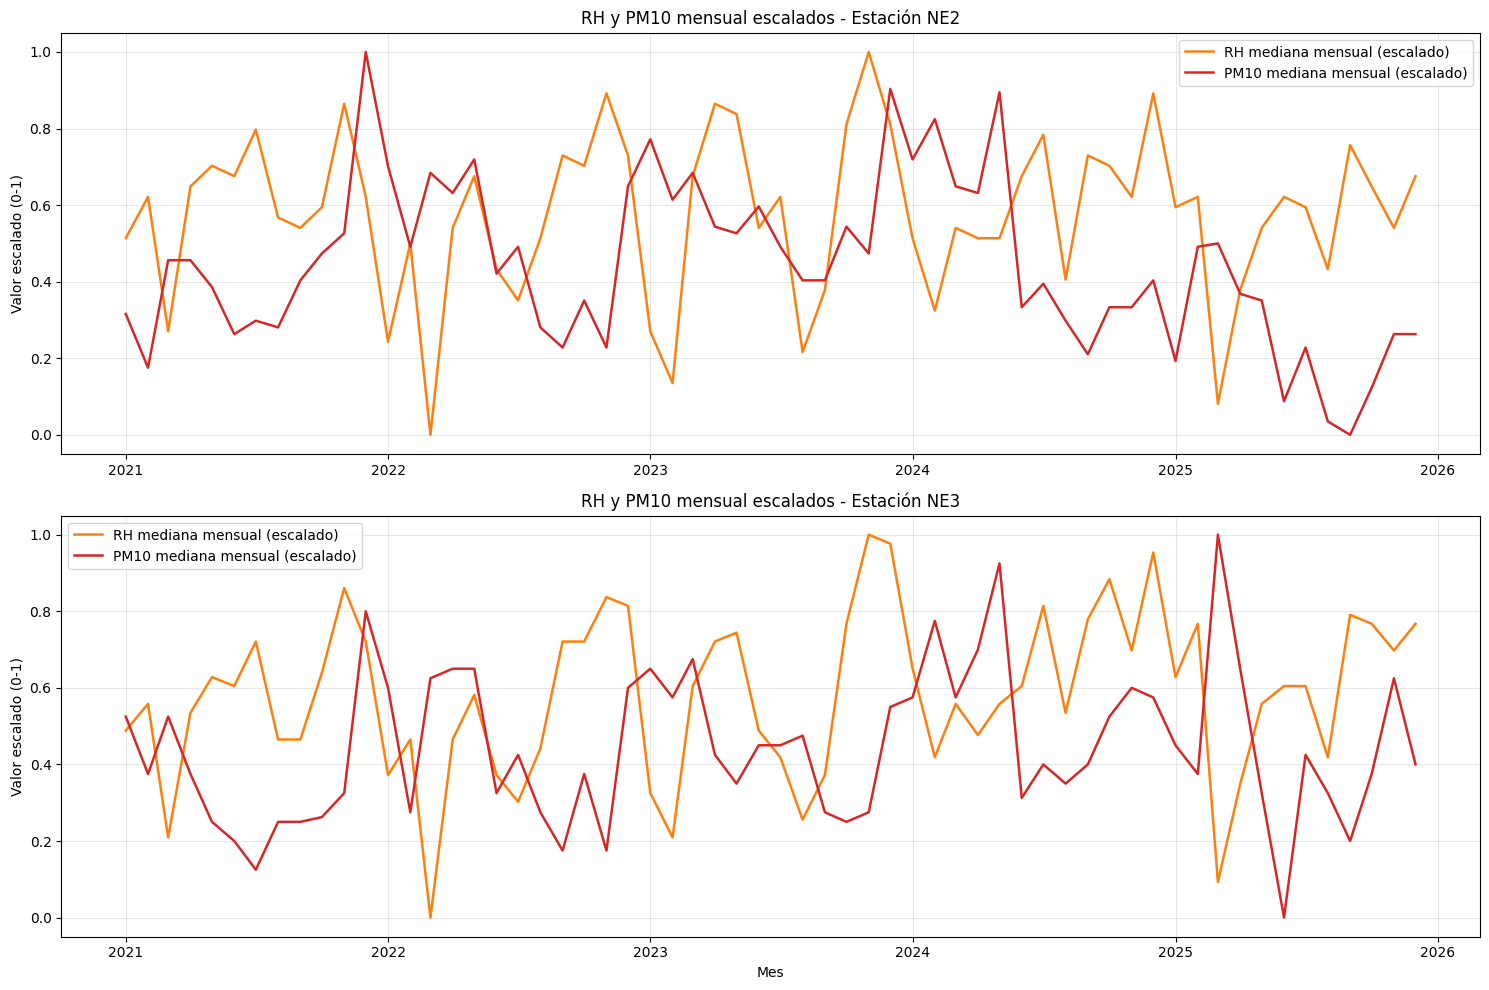

(         mes  rh_mediana  pm10_mediana  rh_escalado  pm10_escalado
 0 2021-01-01        55.0          52.0     0.513514       0.315789
 1 2021-02-01        59.0          44.0     0.621622       0.175439
 2 2021-03-01        46.0          60.0     0.270270       0.456140
 3 2021-04-01        60.0          60.0     0.648649       0.456140
 4 2021-05-01        62.0          56.0     0.702703       0.385965,
          mes  rh_mediana  pm10_mediana  rh_escalado  pm10_escalado
 0 2021-01-01        60.0          36.0     0.488372          0.525
 1 2021-02-01        63.0          30.0     0.558140          0.375
 2 2021-03-01        48.0          36.0     0.209302          0.525
 3 2021-04-01        62.0          30.0     0.534884          0.375
 4 2021-05-01        66.0          25.0     0.627907          0.250)

In [35]:
def preparar_rh_pm10_estacion(datos_estacion):
    """Agrega RH y PM10 por mes para una estación."""
    mensual = (
        datos_estacion.assign(
            mes=datos_estacion["date"].dt.to_period("M").dt.to_timestamp(),
            RH=pd.to_numeric(datos_estacion["RH"], errors="coerce"),
            PM10=pd.to_numeric(datos_estacion["PM10"], errors="coerce"),
        )
        .groupby("mes", as_index=False)
        .agg(rh_mediana=("RH", "median"), pm10_mediana=("PM10", "median"))
    )
    mensual = mensual.sort_values("mes")
    mensual["rh_escalado"] = escalar_min_max(mensual["rh_mediana"])
    mensual["pm10_escalado"] = escalar_min_max(mensual["pm10_mediana"])
    return mensual


serie_rh_pm10_NE2 = preparar_rh_pm10_estacion(NE2)
serie_rh_pm10_NE3 = preparar_rh_pm10_estacion(NE3)

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

for eje, datos, nombre_estacion in zip(
    ejes, [serie_rh_pm10_NE2, serie_rh_pm10_NE3], ["NE2", "NE3"]
):
    eje.plot(datos["mes"], datos["rh_escalado"], label="RH mediana mensual (escalado)",
              color="tab:orange", linewidth=1.8)
    eje.plot(datos["mes"], datos["pm10_escalado"], label="PM10 mediana mensual (escalado)",
              color="tab:red", linewidth=1.8)
    eje.set_title(f"RH y PM10 mensual escalados - Estación {nombre_estacion}")
    eje.set_ylabel("Valor escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()

ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

serie_rh_pm10_NE2.head(), serie_rh_pm10_NE3.head()

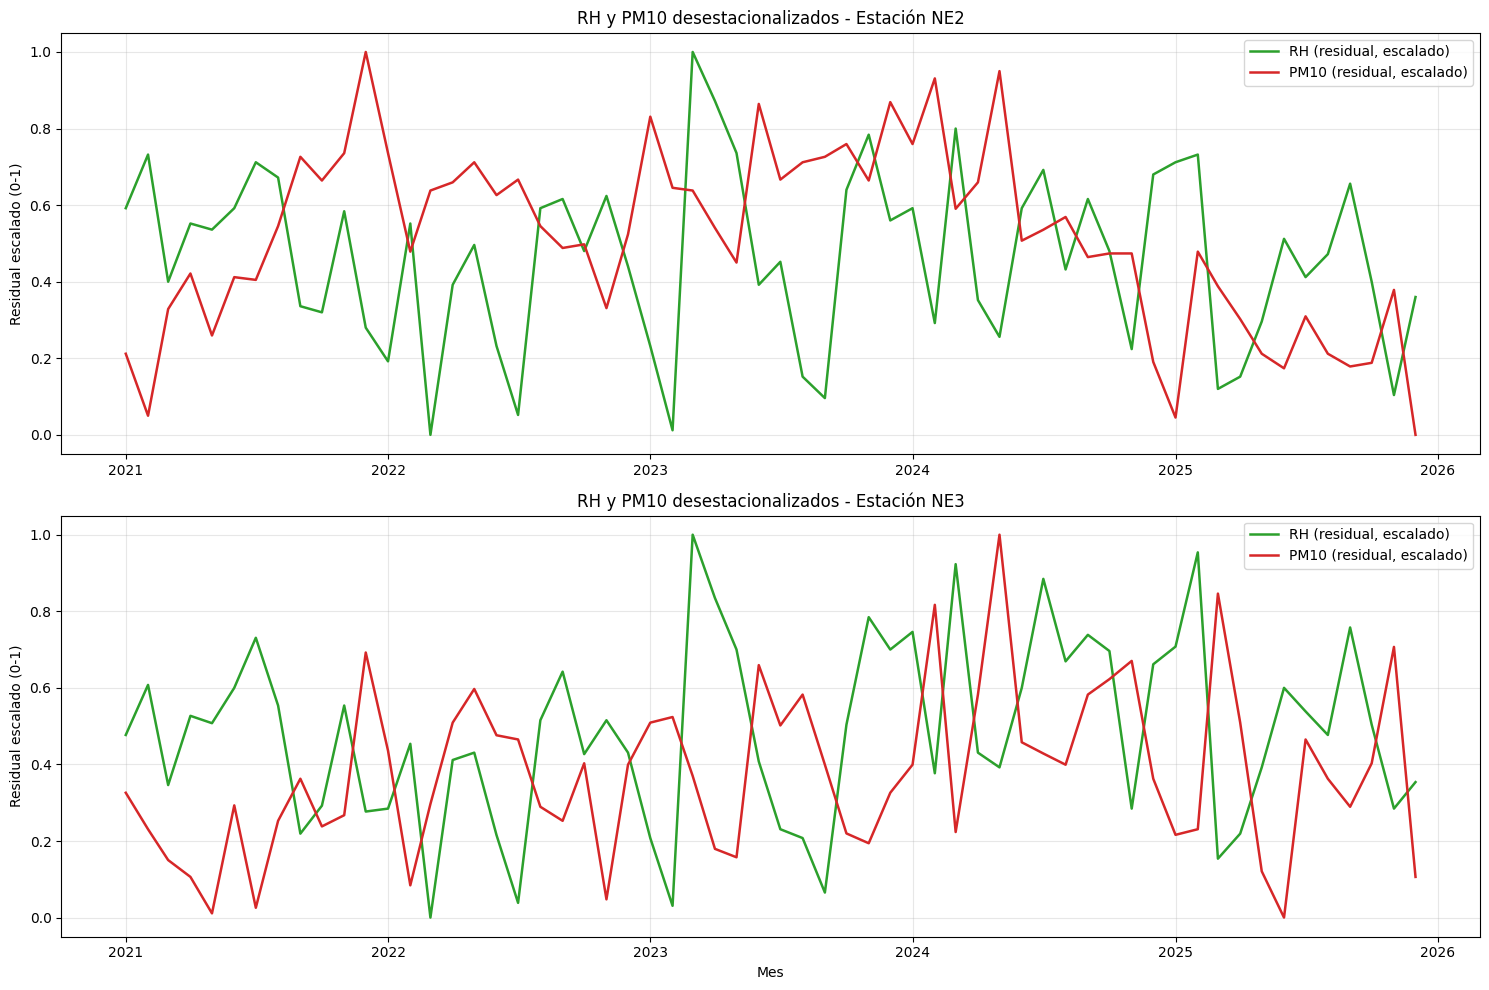

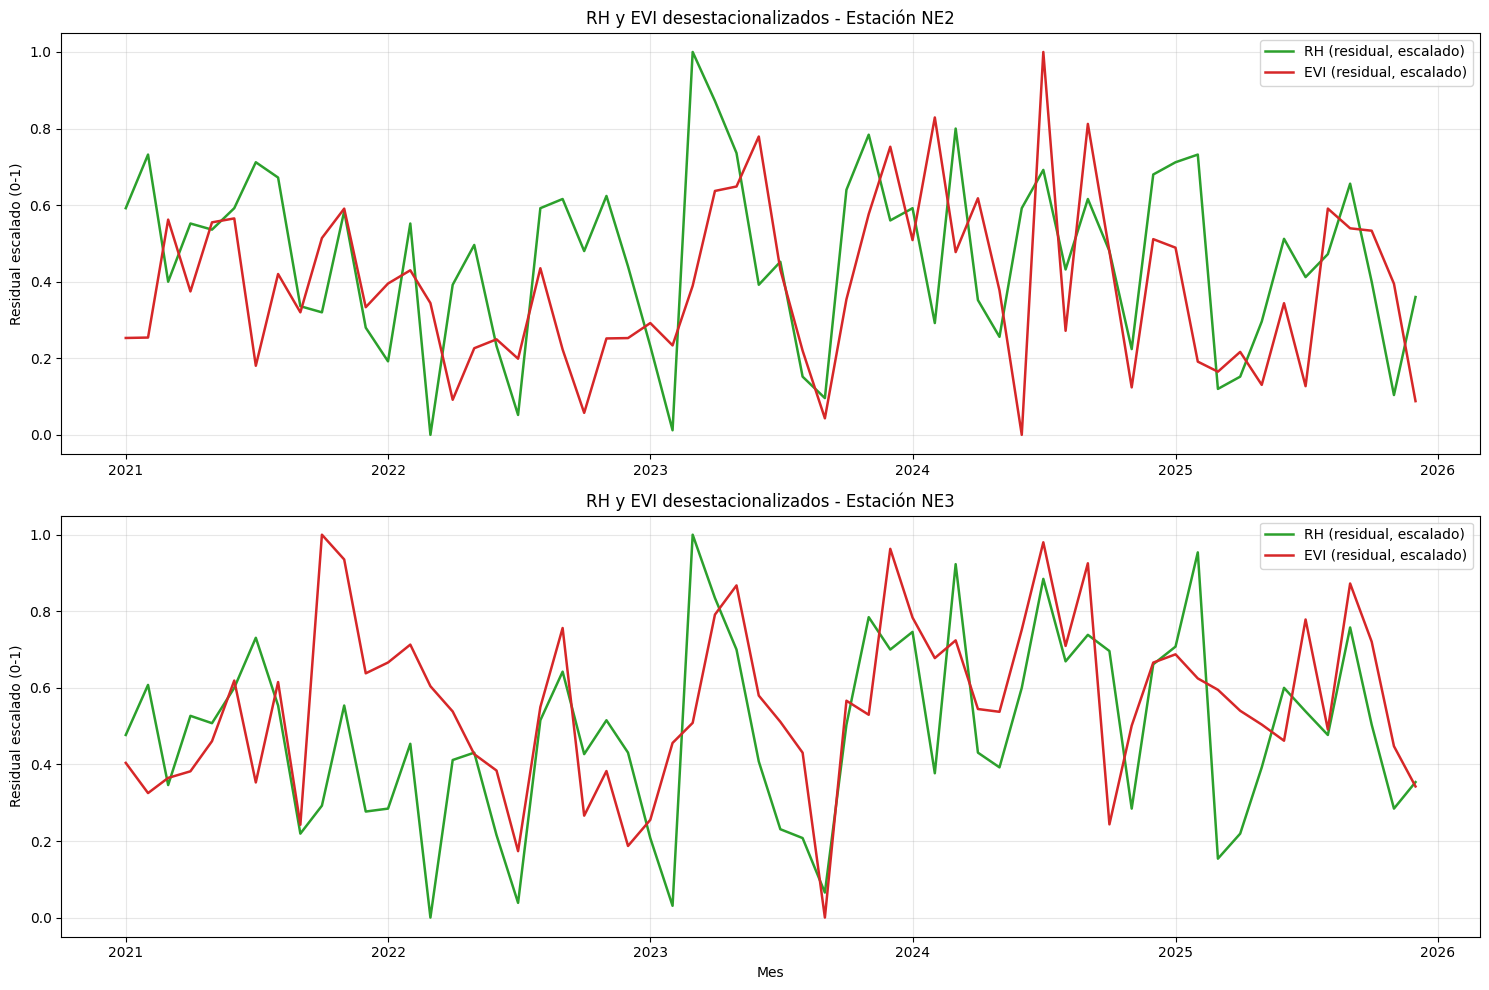

In [41]:
import statsmodels.api as sm

def desestacionalizar(datos, columna):
    """Remueve el efecto de mes (dummy) de una serie, devuelve los residuales."""
    datos = datos.copy()
    datos["mes_num"] = datos["mes"].dt.month
    dummies_mes = pd.get_dummies(datos["mes_num"], prefix="mes", drop_first=True)
    X = sm.add_constant(dummies_mes.astype(float))
    modelo = sm.OLS(datos[columna], X, missing="drop").fit()
    return modelo.resid


def preparar_rh_pm10_desestacionalizado(datos_estacion):
    """RH y PM10 mensuales, desestacionalizados (residuales tras remover efecto de mes)."""
    mensual = (
        datos_estacion.assign(
            mes=datos_estacion["date"].dt.to_period("M").dt.to_timestamp(),
            RH=pd.to_numeric(datos_estacion["RH"], errors="coerce"),
            PM10=pd.to_numeric(datos_estacion["PM10"], errors="coerce"),
        )
        .groupby("mes", as_index=False)
        .agg(rh_mediana=("RH", "median"), pm10_mediana=("PM10", "median"))
    )
    mensual = mensual.sort_values("mes").dropna(subset=["rh_mediana", "pm10_mediana"])

    mensual["rh_resid"] = desestacionalizar(mensual, "rh_mediana")
    mensual["pm10_resid"] = desestacionalizar(mensual, "pm10_mediana")

    # Escalamos los residuales solo para que ambas líneas compartan rango visual
    mensual["rh_resid_escalado"] = escalar_min_max(mensual["rh_resid"])
    mensual["pm10_resid_escalado"] = escalar_min_max(mensual["pm10_resid"])
    return mensual


def preparar_evi_rh_desestacionalizado(datos_estacion, nombre_estacion):
    """EVI y RH mensuales, desestacionalizados."""
    rh_mensual = (
        datos_estacion.assign(
            mes=datos_estacion["date"].dt.to_period("M").dt.to_timestamp(),
            RH=pd.to_numeric(datos_estacion["RH"], errors="coerce"),
        )
        .groupby("mes", as_index=False)["RH"]
        .median()
        .rename(columns={"RH": "rh_mediana"})
    )

    evi_mensual["mes"] = pd.to_datetime(evi_mensual["mes"])
    evi_est = evi_mensual.loc[evi_mensual["estacion"] == nombre_estacion, ["mes", "evi_mediana"]]

    datos = rh_mensual.merge(evi_est, on="mes", how="inner")
    datos = datos.sort_values("mes").dropna(subset=["rh_mediana", "evi_mediana"])

    datos["rh_resid"] = desestacionalizar(datos, "rh_mediana")
    datos["evi_resid"] = desestacionalizar(datos, "evi_mediana")

    datos["rh_resid_escalado"] = escalar_min_max(datos["rh_resid"])
    datos["evi_resid_escalado"] = escalar_min_max(datos["evi_resid"])
    return datos


# --- RH-PM10 desestacionalizado ---
serie_rh_pm10_desest_NE2 = preparar_rh_pm10_desestacionalizado(NE2)
serie_rh_pm10_desest_NE3 = preparar_rh_pm10_desestacionalizado(NE3)

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)
for eje, datos, nombre_estacion in zip(
    ejes, [serie_rh_pm10_desest_NE2, serie_rh_pm10_desest_NE3], ["NE2", "NE3"]
):
    eje.plot(datos["mes"], datos["rh_resid_escalado"], label="RH (residual, escalado)",
              color="tab:green", linewidth=1.8)
    eje.plot(datos["mes"], datos["pm10_resid_escalado"], label="PM10 (residual, escalado)",
              color="tab:red", linewidth=1.8)
    eje.set_title(f"RH y PM10 desestacionalizados - Estación {nombre_estacion}")
    eje.set_ylabel("Residual escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()
ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

# --- EVI-RH desestacionalizado ---
serie_evi_rh_desest_NE2 = preparar_evi_rh_desestacionalizado(NE2, "NE2")
serie_evi_rh_desest_NE3 = preparar_evi_rh_desestacionalizado(NE3, "NE3")

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)
for eje, datos, nombre_estacion in zip(
    ejes, [serie_evi_rh_desest_NE2, serie_evi_rh_desest_NE3], ["NE2", "NE3"]
):
    eje.plot(datos["mes"], datos["rh_resid_escalado"], label="RH (residual, escalado)",
              color="tab:green", linewidth=1.8)
    eje.plot(datos["mes"], datos["evi_resid_escalado"], label="EVI (residual, escalado)",
              color="tab:red", linewidth=1.8)
    eje.set_title(f"RH y EVI desestacionalizados - Estación {nombre_estacion}")
    eje.set_ylabel("Residual escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()
ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

In [37]:
from scipy.stats import pearsonr

r_rh_pm10_NE2, p_rh_pm10_NE2 = pearsonr(serie_rh_pm10_desest_NE2["rh_resid"], serie_rh_pm10_desest_NE2["pm10_resid"])
r_rh_pm10_NE3, p_rh_pm10_NE3 = pearsonr(serie_rh_pm10_desest_NE3["rh_resid"], serie_rh_pm10_desest_NE3["pm10_resid"])
r_evi_rh_NE2, p_evi_rh_NE2 = pearsonr(serie_evi_rh_desest_NE2["evi_resid"], serie_evi_rh_desest_NE2["rh_resid"])
r_evi_rh_NE3, p_evi_rh_NE3 = pearsonr(serie_evi_rh_desest_NE3["evi_resid"], serie_evi_rh_desest_NE3["rh_resid"])

print(f"RH-PM10 NE2: r={r_rh_pm10_NE2:.3f}, p={p_rh_pm10_NE2:.3f}")
print(f"RH-PM10 NE3: r={r_rh_pm10_NE3:.3f}, p={p_rh_pm10_NE3:.3f}")
print(f"EVI-RH NE2:  r={r_evi_rh_NE2:.3f}, p={p_evi_rh_NE2:.3f}")
print(f"EVI-RH NE3:  r={r_evi_rh_NE3:.3f}, p={p_evi_rh_NE3:.3f}")

RH-PM10 NE2: r=-0.249, p=0.055
RH-PM10 NE3: r=-0.371, p=0.004
EVI-RH NE2:  r=0.333, p=0.009
EVI-RH NE3:  r=0.463, p=0.000
